# Cell 1 Overview: Environment Setup

Purpose:
- Installs and pins package versions needed by the notebook.
- Prevents common binary mismatches for datasets and pyarrow dependencies.

Expected output meaning:
- Installation logs show package resolution and versions.
- Warnings can appear, but hard errors must be resolved before moving on.

What to do after this cell:
- Restart kernel once if this is a fresh environment, then run Cell 2.

In [ ]:
# Optional: run once in a fresh environment, then restart kernel
# Fixes binary dependency mismatches (pyarrow/xxhash) seen with datasets imports
%pip install --upgrade --force-reinstall --no-cache-dir "datasets==2.20.0" "pyarrow>=14.0.1,<17.0.0" "pyarrow-hotfix>=0.6" "xxhash==3.5.0" "numexpr>=2.10.2" pandas networkx tqdm matplotlib seaborn python-louvain scipy

  DEPRECATION: Building 'python-louvain' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'python-louvain'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  You can safely remove it manually.
error: uninstall-no-record-file

× Cannot uninstall tqdm None
╰─> The package's contents are unknown: no RECORD file was found for tqdm.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps tqdm==4.67.1



  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/547.8 kB ? eta -:--:--
   ---------------------------------------- 547.8/547.8 kB 9.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/25.8 MB ? eta -:--:--
   --------------------- ------------------ 13.6/25.8 MB 65.9 MB/s eta 0:00:01
   ---------------------------------------- 25.8/25.8 MB 86.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 9.7/9.7 MB 121.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 112.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---

## Cell 2 Overview: Imports, Parameters, and Run Configuration

Purpose:
- Imports all libraries used in data collection, analysis, and network modeling.
- Defines experiment parameters: subreddits, month shard, sample caps, and output folder.
- Validates that selected month exists in the dataset.

Expected output meaning:
- Printed parameter block is the run contract for reproducibility.
- If month validation fails, update year and month settings to supported shard range.

In [9]:
# Imports and parameters
try:
    from datasets import load_dataset
except Exception as e:
    raise RuntimeError(
        "Failed to import datasets. Run Cell 1 to install compatible versions, then restart the kernel and rerun Cell 2."
    ) from e
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict, deque, Counter
import os
from datetime import datetime, timezone
from community import community_louvain
from scipy.stats import mannwhitneyu

sns.set(style="whitegrid", context="talk")

# --- EDIT THESE PARAMETERS ---
SUBREDDITS = ["politics", "worldnews", "technology"]   # pick 1-4 subreddits

# Fast mode: this HF dataset only has monthly shards from 2012-01 to 2016-02.
START_YEAR = 2015
START_MONTH = 1
END_YEAR = 2015
END_MONTH = 1

MAX_COMMENTS = 40000    # targeted comments to collect
MAX_POSTS = None         # optional cap on distinct posts in final sample
RANDOM_SEED = 42

# Densification controls (active-thread targeting)
MAX_SCAN = 20000         # qualifying comments scanned in pass 1
TOP_K_ACTIVE_POSTS = 80  # keep top-K busiest posts in selected subreddits

# Safety caps: raw stream rows to prevent runaway runtimes
MAX_RAW_PASS1 = 1500000
MAX_RAW_PASS2 = 2500000

OUT_DIR = "hf_stream_slice"
os.makedirs(OUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)

# Inclusive month window in UTC
START_TS = int(datetime(START_YEAR, START_MONTH, 1, tzinfo=timezone.utc).timestamp())
if END_MONTH == 12:
    END_TS = int(datetime(END_YEAR + 1, 1, 1, tzinfo=timezone.utc).timestamp()) - 1
else:
    END_TS = int(datetime(END_YEAR, END_MONTH + 1, 1, tzinfo=timezone.utc).timestamp()) - 1

def in_time_window(created_utc):
    try:
        t = int(float(created_utc))
    except Exception:
        return False
    return START_TS <= t <= END_TS

# Available shards in this dataset: 2012-01 ... 2016-02
AVAILABLE_MONTHS = {f"{y:04d}-{m:02d}" for y in range(2012, 2016) for m in range(1, 13)} | {"2016-01", "2016-02"}
MONTH_KEY = f"{START_YEAR:04d}-{START_MONTH:02d}"
if (START_YEAR, START_MONTH) != (END_YEAR, END_MONTH):
    raise ValueError("Fast mode expects START and END to be the same month.")
if MONTH_KEY not in AVAILABLE_MONTHS:
    raise ValueError(f"Month {MONTH_KEY} is not available in this dataset (supported: 2012-01 to 2016-02).")
MONTH_FILE = f"data/RC_{MONTH_KEY}.parquet"

print("Parameters:")
print("Subreddits:", SUBREDDITS)
print("Month shard:", MONTH_FILE)
print("Max comments target:", MAX_COMMENTS)
print("Pass-1 qualifying target:", MAX_SCAN)
print("Top active posts kept:", TOP_K_ACTIVE_POSTS)
print("Raw safety caps (pass1/pass2):", MAX_RAW_PASS1, MAX_RAW_PASS2)
print("UTC window:", START_TS, "to", END_TS)
print("Output dir:", OUT_DIR)

Parameters:
Subreddits: ['politics', 'worldnews', 'technology']
Month shard: data/RC_2015-01.parquet
Max comments target: 40000
Pass-1 qualifying target: 20000
Top active posts kept: 80
Raw safety caps (pass1/pass2): 1500000 2500000
UTC window: 1420070400 to 1422748799
Output dir: hf_stream_slice


## Cell 3 Overview: Two-Pass Targeted Comment Collection

Purpose:
- Pass 1 finds active posts in selected subreddits within the chosen month shard.
- Pass 2 collects comments only from those active posts to produce dense cascades.
- Saves the sampled comments to CSV for traceability.

Expected output meaning:
- Pass 1 output reports raw rows scanned and number of active posts selected.
- Pass 2 output reports final comment count and post coverage.
- Reaching raw safety caps means bounded sampling, not necessarily a failure.

In [10]:
# Two-pass collection for denser thread structure using a single monthly shard (fast mode).
dataset_id = "fddemarco/pushshift-reddit-comments"
print("Loading dataset shard (streaming)...", dataset_id, MONTH_FILE)

target_subs = {s.lower() for s in SUBREDDITS}

# ---------- Pass 1: identify active posts ----------
stream1 = load_dataset(
    dataset_id,
    data_files={"train": MONTH_FILE},
    split="train",
    streaming=True
 )
post_counter = Counter()
scanned = 0
raw_seen1 = 0

for item in tqdm(stream1, total=None, desc="Pass 1: scanning selected month"):
    raw_seen1 += 1
    if MAX_RAW_PASS1 and raw_seen1 >= MAX_RAW_PASS1:
        print(f"Reached MAX_RAW_PASS1={MAX_RAW_PASS1} before hitting qualifying target.")
        break

    sub = item.get("subreddit")
    if not sub or sub.lower() not in target_subs:
        continue

    lk = item.get("link_id")
    if lk:
        post_counter[str(lk).replace("t3_", "")] += 1
        scanned += 1

    if scanned >= MAX_SCAN:
        break

TOP_POSTS = [pid for pid, _ in post_counter.most_common(TOP_K_ACTIVE_POSTS)]
TOP_POSTS_SET = set(TOP_POSTS)
print(f"Pass 1 matched={scanned}, raw_seen={raw_seen1}, active_posts={len(TOP_POSTS)}")
print("Top 5 active post IDs:", post_counter.most_common(5))

# ---------- Pass 2: collect comments from active posts ----------
stream2 = load_dataset(
    dataset_id,
    data_files={"train": MONTH_FILE},
    split="train",
    streaming=True
 )
rows = []
post_set = set()
count = 0
raw_seen2 = 0

for item in tqdm(stream2, total=None, desc="Pass 2: collecting targeted comments"):
    raw_seen2 += 1
    if MAX_RAW_PASS2 and raw_seen2 >= MAX_RAW_PASS2:
        print(f"Reached MAX_RAW_PASS2={MAX_RAW_PASS2} before hitting comment target.")
        break

    try:
        sub = item.get("subreddit")
        if not sub or sub.lower() not in target_subs:
            continue

        link_id = str(item.get("link_id") or "").replace("t3_", "")
        if link_id not in TOP_POSTS_SET:
            continue

        rows.append({
            "id": item.get("id"),
            "parent_id": item.get("parent_id"),
            "link_id": item.get("link_id"),
            "author": item.get("author"),
            "subreddit": item.get("subreddit"),
            "created_utc": item.get("created_utc"),
            "score": item.get("score"),
            "controversiality": int(item.get("controversiality") or 0),
            "body": item.get("body")
        })
        count += 1
        post_set.add(link_id)

        if MAX_COMMENTS and count >= MAX_COMMENTS:
            break
        if MAX_POSTS and len(post_set) >= MAX_POSTS:
            break
    except Exception:
        continue

print(f"Collected {len(rows)} targeted comments across {len(post_set)} active posts.")
print(f"Pass 2 raw rows seen: {raw_seen2}")
df = pd.DataFrame(rows)
df.to_csv(os.path.join(OUT_DIR, f"comments_targeted_{MONTH_KEY}.csv"), index=False)
df.head()

Loading dataset shard (streaming)... fddemarco/pushshift-reddit-comments data/RC_2015-01.parquet


Pass 1: scanning selected month: 0it [00:00, ?it/s]

Pass 1 matched=20000, raw_seen=1125658, active_posts=80
Top 5 active post IDs: [('2qzqxm', 3596), ('2qygtn', 1406), ('2r0nvr', 1089), ('2r05jv', 1015), ('2qxelx', 810)]


Pass 2: collecting targeted comments: 0it [00:00, ?it/s]

Reached MAX_RAW_PASS2=2500000 before hitting comment target.
Collected 27067 targeted comments across 80 active posts.
Pass 2 raw rows seen: 2500000


,id,parent_id,link_id,author,subreddit,created_utc,score,controversiality,body
0,cnas90q,None,t3_2qxiaz,uncannylizard,worldnews,1420070401,0,0,the vast majority of countries in the world re...
1,cnas95y,None,t3_2qwwic,keyhole_six,politics,1420070411,1,0,oh this is really interesting - - i thought ny...
2,cnas99h,None,t3_2qx8cd,c00ki3mnstr,politics,1420070417,-1,0,"yeah , i live here , and i don ' t see the sub..."
3,cnas9a8,None,t3_2qx8cd,DrMasterBlaster,politics,1420070419,1,0,"they voted for the mayor , not the police offi..."
4,cnas9h8,None,t3_2qxljz,9minutetruth-penalty,worldnews,1420070431,0,0,a false equivalency .


## Cell 4 Overview: Data Cleaning and Identifier Normalization

Purpose:
- Cleans IDs and removes Reddit prefixes for consistent joins and grouping.
- Converts key columns to numeric types used in downstream metrics.
- Standardizes missing values for robust processing.

Expected output meaning:
- Shape confirms usable sample size after cleaning.
- Preview confirms normalized identifiers and analysis fields are ready.

In [11]:
# Preprocess IDs: strip t1_/t3_ prefixes and ensure strings
def strip_prefix(x):
    if pd.isna(x): return x
    s = str(x)
    return s.replace("t1_", "").replace("t3_", "")

df['id'] = df['id'].astype(str)
df['parent_id_raw'] = df['parent_id'].astype(str)
df['parent_id_clean'] = df['parent_id_raw'].apply(lambda x: strip_prefix(x) if x not in ["None", "nan"] else "")
df['link_id_clean'] = df['link_id'].astype(str).apply(lambda x: strip_prefix(x) if x not in ["None", "nan"] else "")
df['author'] = df['author'].astype(str)
df['created_utc'] = pd.to_numeric(df['created_utc'], errors='coerce')
df['score'] = pd.to_numeric(df['score'], errors='coerce').fillna(0).astype(int)
df['controversiality'] = df['controversiality'].fillna(0).astype(int)

print("After cleaning:", df.shape)
df[['id','parent_id_clean','link_id_clean','author','subreddit','score','controversiality']].head()

After cleaning: (27067, 12)


,id,parent_id_clean,link_id_clean,author,subreddit,score,controversiality
0,cnas90q,NaN,2qxiaz,uncannylizard,worldnews,0,0
1,cnas95y,NaN,2qwwic,keyhole_six,politics,1,0
2,cnas99h,NaN,2qx8cd,c00ki3mnstr,politics,-1,0
3,cnas9a8,NaN,2qx8cd,DrMasterBlaster,politics,1,0
4,cnas9h8,NaN,2qxljz,9minutetruth-penalty,worldnews,0,0


## Cell 5 Overview: Post Aggregation and Proxy Controversy Score

Purpose:
- Aggregates comments to post-level statistics.
- Builds a proxy controversy score from controversiality fraction and activity-adjusted term.
- Creates binary post label by top quantile threshold.

Expected output meaning:
- Output table is one row per post.
- post_controversial indicates which posts are treated as controversial in comparisons.

In [12]:
# Compute per-post aggregates (num_comments, num_controversial_comments, mean_score)
post_grp = df.groupby('link_id_clean').agg(
    num_comments = ('id','count'),
    num_controversial_comments = ('controversiality','sum'),
    mean_score = ('score','mean')
).reset_index().rename(columns={'link_id_clean':'post_id'})

# Derive a post-level controversy score and label:
# We do this because many comment-only datasets do not include the submission's explicit controversiality flag.
# Heuristic (transparent): controversy_score = fraction_controversial_comments + 0.3*(num_comments/(mean_score+1))
# Then label top 20% posts by controversy_score as controversial (1) and bottom 80% as non-controversial (0)
post_grp['frac_contro'] = post_grp['num_controversial_comments'] / post_grp['num_comments']
post_grp['controversy_score'] = post_grp['frac_contro'] + 0.3*(post_grp['num_comments'] / (post_grp['mean_score'].abs()+1))
# handle NaNs
post_grp['controversy_score'] = post_grp['controversy_score'].fillna(0)
# label threshold: top 20% controversial
pct = 0.20
threshold = post_grp['controversy_score'].quantile(1-pct)
post_grp['post_controversial'] = (post_grp['controversy_score'] >= threshold).astype(int)

print("Posts aggregated:", post_grp.shape)
post_grp.head()

Posts aggregated: (80, 7)


,post_id,num_comments,num_controversial_comments,mean_score,frac_contro,controversy_score,post_controversial
0,2qnurf,49,0,1.000000,0.0,7.350000,0
1,2qtmj3,38,0,1.000000,0.0,5.700000,0
2,2qux5j,47,0,1.000000,0.0,7.050000,0
3,2qviho,83,0,0.939759,0.0,12.836646,0
4,2qw1p4,97,0,1.175258,0.0,13.377725,0


## Cell 6 Overview: Mapping Post Labels Back to Comments

Purpose:
- Transfers post-level controversial label to each comment.
- Exports labeled comments and post aggregate tables to disk.

Expected output meaning:
- Value counts show class distribution in the comment-level dataset.
- Saved files are inputs for cascade and network stages.

In [13]:
# Map post label to comments
post_label_map = post_grp.set_index('post_id')['post_controversial'].to_dict()
df['post_controversial'] = df['link_id_clean'].map(post_label_map).fillna(0).astype(int)

# Save interim data
df.to_csv(os.path.join(OUT_DIR, "comments_with_post_labels.csv"), index=False)
post_grp.to_csv(os.path.join(OUT_DIR, "post_aggregates.csv"), index=False)

print("Comments with post label saved. Example distribution:")
print(df['post_controversial'].value_counts())

Comments with post label saved. Example distribution:
post_controversial
1    18850
0     8217
Name: count, dtype: int64


## Cell 7 Overview: Cascade Metric Function Definition

Purpose:
- Defines reusable function to compute per-post cascade metrics.
- Computes size, depth, unique users, lifespan, and branching proxy.

Expected output meaning:
- This cell usually has no printed output.
- Successful execution means metric logic is ready for batch application.

In [14]:
from collections import defaultdict, deque

def compute_cascade_metrics_for_post(post_id, comments_df):
    cs = comments_df[comments_df['link_id_clean']==str(post_id)].copy()
    if cs.empty:
        return None
    # Prepare children map
    ids = cs['id'].astype(str).tolist()
    id_set = set(ids)
    children = defaultdict(list)
    for _, r in cs.iterrows():
        cid = str(r['id'])
        pid = r['parent_id_clean'] if pd.notna(r['parent_id_clean']) else ''
        # if parent id is empty or equals the post id, that means a top-level comment replying to submission
        children[pid].append(cid)
    # identify roots: comments whose parent is the post (parent == post_id) or parent not in id_set
    roots = [cid for cid in ids if (cs.loc[cs['id']==cid,'parent_id_clean'].values[0] == str(post_id))
             or (cs.loc[cs['id']==cid,'parent_id_clean'].values[0] not in id_set)]
    # BFS for depth
    max_depth = 0
    q = deque()
    for r in roots:
        q.append((r,1))
    visited = set()
    while q:
        node, depth = q.popleft()
        max_depth = max(max_depth, depth)
        visited.add(node)
        for ch in children.get(node, []):
            if ch not in visited:
                q.append((ch, depth+1))
    total_nodes = len(id_set)
    unique_users = cs['author'].nunique() if 'author' in cs.columns else np.nan
    # lifespan (seconds)
    if 'created_utc' in cs.columns:
        times = cs['created_utc'].dropna().astype(float).sort_values()
        lifespan = float(times.max() - times.min()) if len(times) > 1 else 0.0
    else:
        lifespan = np.nan
    # branching: edges/internals (approx)
    internal_nodes = sum(1 for k,v in children.items() if k in id_set and len(v)>0)
    branching = (total_nodes - 1) / internal_nodes if internal_nodes > 0 else np.nan
    return {
        'post_id': post_id,
        'cascade_size': total_nodes,
        'max_depth': max_depth,
        'unique_users': unique_users,
        'lifespan_sec': lifespan,
        'branching': branching
    }

## Cell 8 Overview: Batch Cascade Metric Computation

Purpose:
- Applies cascade metric function across all posts.
- Produces cascade_metrics table used for statistical comparison.

Expected output meaning:
- Progress bar indicates per-post processing.
- Output table confirms one metrics row per analyzed post.

In [15]:
# Compute metrics for all posts in post_grp (or optionally subset top-K by num_comments)
posts = post_grp['post_id'].astype(str).tolist()
metrics = []
for pid in tqdm(posts, desc="Computing post cascades"):
    m = compute_cascade_metrics_for_post(pid, df)
    if m:
        m['post_controversial'] = int(post_label_map.get(pid, 0))
        metrics.append(m)
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(os.path.join(OUT_DIR, "cascade_metrics.csv"), index=False)
metrics_df.head()

Computing post cascades:   0%|          | 0/80 [00:00<?, ?it/s]

,post_id,cascade_size,max_depth,unique_users,lifespan_sec,branching,post_controversial
0,2qnurf,49,1,4,111555.0,NaN,0
1,2qtmj3,38,1,28,138981.0,NaN,0
2,2qux5j,47,1,16,143832.0,NaN,0
3,2qviho,83,1,34,149309.0,NaN,0
4,2qw1p4,97,1,58,105019.0,NaN,0


## Cell 9 Overview: Cascade Distribution Plots and Mann-Whitney Test

Purpose:
- Visualizes cascade size and depth distributions by controversy label.
- Tests whether groups differ statistically using Mann-Whitney U.

Expected output meaning:
- Boxplots show distribution shape and heavy-tail behavior.
- Reported p-value quantifies whether observed group differences are statistically significant.

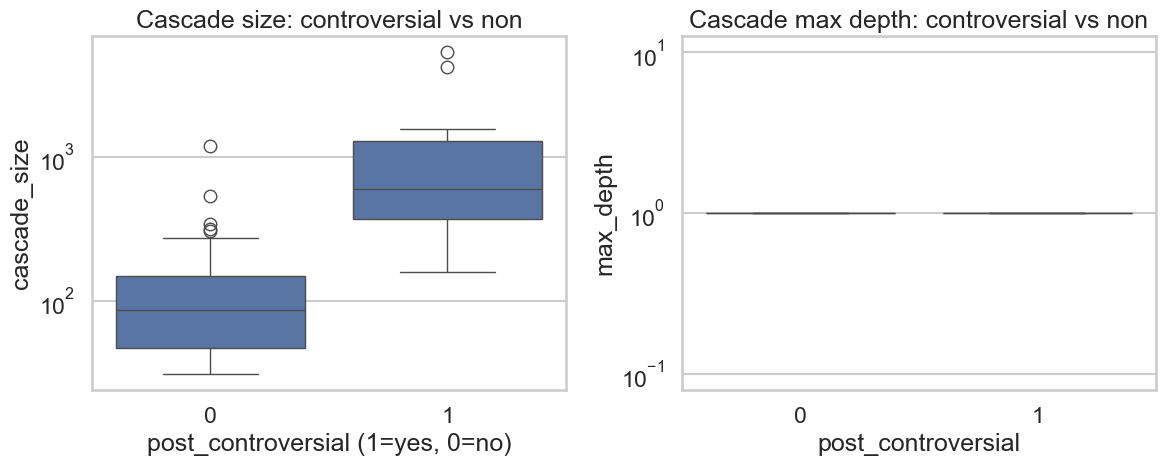

Mann-Whitney U: cascade_size stat=984.500 p=1.364e-08


In [16]:
# Boxplots (use log scale for heavy-tailed distributions)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=metrics_df, x='post_controversial', y='cascade_size')
plt.yscale('log')
plt.xlabel('post_controversial (1=yes, 0=no)')
plt.title('Cascade size: controversial vs non')

plt.subplot(1,2,2)
sns.boxplot(data=metrics_df, x='post_controversial', y='max_depth')
plt.yscale('log')
plt.xlabel('post_controversial')
plt.title('Cascade max depth: controversial vs non')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cascade_size_depth_boxplots.png"), dpi=150, bbox_inches='tight')
plt.show()

# Mann-Whitney U tests (non-parametric)
c1 = metrics_df[metrics_df['post_controversial']==1]['cascade_size'].dropna()
c0 = metrics_df[metrics_df['post_controversial']==0]['cascade_size'].dropna()
if len(c1)>0 and len(c0)>0:
    stat, p = mannwhitneyu(c1, c0, alternative='two-sided')
    print("Mann-Whitney U: cascade_size stat=%.3f p=%.3e" % (stat, p))

## Cell 10 Overview: User Interaction Graph Construction

Purpose:
- Builds undirected co-comment graph where users connect if they comment on the same post.
- Adds edge weights by repeated co-participation across posts.

Expected output meaning:
- Nodes correspond to unique valid users.
- Edges capture co-participation structure, enabling community and centrality analysis.

In [21]:
# Build undirected user co-comment graph from df (reply IDs are unavailable in this dataset)
from itertools import combinations

G = nx.Graph()

# Remove deleted/empty authors early
valid_df = df[~df['author'].isin(['', '[deleted]', 'None', 'nan'])].copy()
valid_df['author'] = valid_df['author'].astype(str)

# Build per-post user sets; cap users per post to avoid combinatorial blowups
MAX_USERS_PER_POST = 400
post_users = valid_df.groupby('link_id_clean')['author'].apply(lambda s: sorted(set(s))).to_dict()

for post_id, users in tqdm(post_users.items(), desc='Building user co-comment graph'):
    if not users:
        continue
    users = users[:MAX_USERS_PER_POST]
    G.add_nodes_from(users)
    for u, v in combinations(users, 2):
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)

print(f'User graph nodes: {G.number_of_nodes()}')
print(f'User graph edges: {G.number_of_edges()}')

G_und = G

Building user co-comment graph:   0%|          | 0/80 [00:00<?, ?it/s]

User graph nodes: 7251
User graph edges: 1030721


## Cell 11 Overview: Global Network Metrics and Degree Distribution

Purpose:
- Computes graph size, density, and clustering.
- Plots degree distribution on log scales.

Expected output meaning:
- Higher clustering suggests tightly knit local neighborhoods.
- Degree histogram reveals heterogeneity and hub-like users.

Nodes: 7251 Edges: 1030721 Density: 0.0392134640168538 Avg clustering: 0.9371352770831205


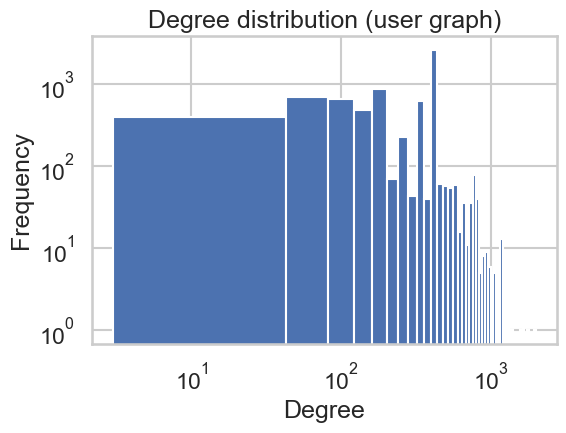

In [22]:
# Basic network metrics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G) if num_nodes > 0 else 0
G_und = G.to_undirected() if num_nodes > 0 else nx.Graph()
avg_clustering = nx.average_clustering(G_und) if num_nodes > 0 else np.nan

print("Nodes:", num_nodes, "Edges:", num_edges, "Density:", density, "Avg clustering:", avg_clustering)

# Degree distribution histogram (log-log)
deg_seq = [d for _, d in G_und.degree()] if num_nodes > 0 else []
deg_seq_pos = [d for d in deg_seq if d > 0]

plt.figure(figsize=(6,4))
if len(deg_seq_pos) > 0:
    plt.hist(deg_seq_pos, bins=50)
    plt.xscale('log')
    plt.yscale('log')
else:
    plt.text(0.5, 0.5, 'No positive-degree nodes to plot', ha='center', va='center')
    plt.axis('off')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree distribution (user graph)')
plt.savefig(os.path.join(OUT_DIR,'degree_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 Overview: User Centrality Analysis

Purpose:
- Computes degree, betweenness, closeness, and eigenvector centralities.
- Produces ranked user table for influence interpretation.

Expected output meaning:
- Top rows identify structurally prominent users in this network model.
- Non-zero eigenvector values confirm stable centrality estimation.

In [24]:
# Centrality on the user graph
if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
    deg_cent = nx.degree_centrality(G)

    # Betweenness centrality: approximate if graph is large
    if G.number_of_nodes() > 2000:
        bet_cent = nx.betweenness_centrality(G, k=200, seed=RANDOM_SEED)
    else:
        bet_cent = nx.betweenness_centrality(G)

    close_cent = nx.closeness_centrality(G)
    try:
        # Power-iteration method is more stable than eigenvector_centrality_numpy on large sparse graphs
        eig_cent = nx.eigenvector_centrality(G_und, max_iter=1000, tol=1e-06)
    except Exception as e:
        print(f"Eigenvector centrality failed: {e}")
        eig_cent = {}

    users = list(deg_cent.keys())
    central_df = pd.DataFrame({
        'user': users,
        'degree_centrality': [deg_cent.get(u, 0) for u in users],
        'betweenness': [bet_cent.get(u, 0) for u in users],
        'closeness': [close_cent.get(u, 0) for u in users],
        'eigenvector': [eig_cent.get(u, 0) for u in users]
    })
    central_df = central_df.sort_values('degree_centrality', ascending=False).reset_index(drop=True)
    display(central_df.head(20))
else:
    central_df = pd.DataFrame(columns=['user', 'degree_centrality', 'betweenness', 'closeness', 'eigenvector'])
    print("Graph is empty. Rerun Cell 10 (graph build) and Cell 11 (metrics) before this cell.")

,user,degree_centrality,betweenness,closeness,eigenvector
0,Balrogic3,0.272276,0.018129,0.575813,0.065341
1,bitofnewsbot,0.242345,0.027773,0.563361,0.021860
2,Voduar,0.224966,0.026480,0.562093,0.029845
3,ivan82,0.224138,0.011063,0.559617,0.031772
4,Shadow_Prime,0.214759,0.010696,0.552698,0.056199
5,Scattered_Disk,0.187310,0.012199,0.545989,0.026886
6,StinkinFinger,0.178483,0.007552,0.543042,0.033498
7,Rench15,0.177517,0.008968,0.540125,0.017912
8,TangoJager,0.177103,0.017393,0.545044,0.029621
9,APeacefulWarrior,0.167586,0.013188,0.536484,0.032102


## Cell 13 Overview: Community Detection (Louvain)

Purpose:
- Detects communities in the undirected user graph.
- Computes modularity as a summary of community structure strength.

Expected output meaning:
- Number of communities gives segmentation granularity.
- Higher modularity indicates clearer community boundaries in interaction structure.

In [25]:
# Run Louvain on undirected graph
if G_und.number_of_nodes() > 0 and G_und.number_of_edges() > 0:
    partition = community_louvain.best_partition(G_und)
    num_communities = len(set(partition.values()))
    mod = community_louvain.modularity(partition, G_und)
    print("Detected communities:", num_communities, "Modularity:", mod)
    # Save partition mapping
    part_df = pd.DataFrame(list(partition.items()), columns=['user','community'])
    part_df.to_csv(os.path.join(OUT_DIR,'user_communities.csv'), index=False)
else:
    partition = {}
    mod = np.nan
    part_df = pd.DataFrame()

Detected communities: 17 Modularity: 0.7698715653790231


## Cell 14 Overview: Community Spread per Cascade

Purpose:
- Maps cascade participants to detected communities.
- Measures how broadly each post spans communities.

Expected output meaning:
- num_communities_known shows breadth across communities.
- frac_communities_known normalizes spread by participant count.

In [26]:
# Map users to communities (if present)
user_comm = partition

comm_spread = []
for _, row in tqdm(metrics_df.iterrows(), total=metrics_df.shape[0], desc="Community spread per cascade"):
    pid = str(row['post_id'])
    cs = df[df['link_id_clean']==pid]
    if cs.empty:
        continue
    authors = cs['author'].dropna().astype(str).unique().tolist()
    comms = set([user_comm.get(a, -1) for a in authors])
    num_known = len([c for c in comms if c!=-1])
    frac_known = num_known / (len(authors) if len(authors)>0 else 1)
    comm_spread.append({
        'post_id': pid,
        'cascade_size': row['cascade_size'],
        'num_communities_known': num_known,
        'frac_communities_known': frac_known,
        'post_controversial': int(row['post_controversial'])
    })

comm_spread_df = pd.DataFrame(comm_spread)
comm_spread_df.to_csv(os.path.join(OUT_DIR,'community_spread.csv'), index=False)
comm_spread_df.head()

Community spread per cascade:   0%|          | 0/80 [00:00<?, ?it/s]

,post_id,cascade_size,num_communities_known,frac_communities_known,post_controversial
0,2qnurf,49,1,0.250000,0
1,2qtmj3,38,3,0.107143,0
2,2qux5j,47,6,0.375000,0
3,2qviho,83,4,0.117647,0
4,2qw1p4,97,5,0.086207,0


## Cell 15 Overview: Community Spread Comparison and Significance

Purpose:
- Visualizes community-spread differences by controversy label.
- Runs Mann-Whitney U test for group-level significance.

Expected output meaning:
- Boxplot compares central tendency and dispersion between groups.
- p-value indicates whether observed spread differences are statistically credible.

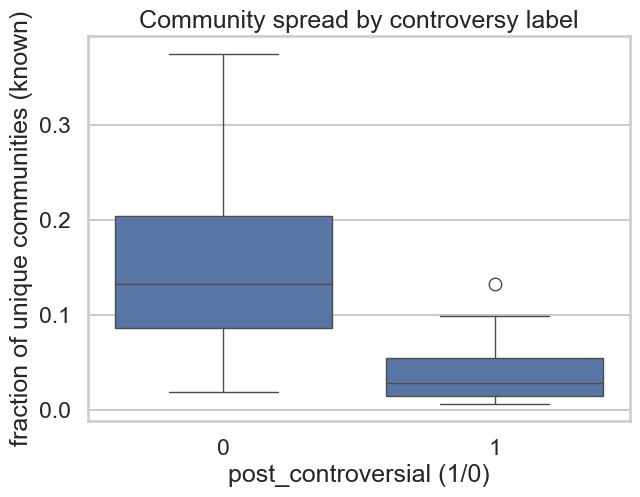

Mann-Whitney community spread: stat=89.500 p=3.852e-07


In [27]:
plt.figure(figsize=(7,5))
sns.boxplot(data=comm_spread_df, x='post_controversial', y='frac_communities_known')
plt.xlabel('post_controversial (1/0)')
plt.ylabel('fraction of unique communities (known)')
plt.title('Community spread by controversy label')
plt.savefig(os.path.join(OUT_DIR,'community_spread_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

v1 = comm_spread_df[comm_spread_df['post_controversial']==1]['frac_communities_known'].dropna()
v0 = comm_spread_df[comm_spread_df['post_controversial']==0]['frac_communities_known'].dropna()
if len(v1)>10 and len(v0)>10:
    st, p = mannwhitneyu(v1, v0, alternative='two-sided')
    print("Mann-Whitney community spread: stat=%.3f p=%.3e" % (st, p))
else:
    print("Not enough samples for robust test.")

## Cell 16 Overview: Final Export and Run Summary

Purpose:
- Saves final metrics, centralities, and summary file to output directory.
- Produces compact run summary for report insertion.

Expected output meaning:
- Printed summary confirms final sample and network scale.
- CSV outputs are the authoritative artifacts for results and write-up.

In [28]:
metrics_df.to_csv(os.path.join(OUT_DIR,'cascade_metrics_full.csv'), index=False)
central_df.to_csv(os.path.join(OUT_DIR,'user_centralities_full.csv'), index=False)
summary = {
    'num_comments': int(df.shape[0]),
    'num_posts': int(post_grp.shape[0]),
    'num_posts_analyzed': int(metrics_df.shape[0]),
    'num_users': int(G.number_of_nodes()),
    'num_user_edges': int(G.number_of_edges()),
    'modularity': float(mod if not np.isnan(mod) else -1)
}
pd.Series(summary).to_csv(os.path.join(OUT_DIR,'analysis_summary.csv'))
print("All outputs saved to", OUT_DIR)
summary

All outputs saved to hf_stream_slice


{'num_comments': 27067,
 'num_posts': 80,
 'num_posts_analyzed': 80,
 'num_users': 7251,
 'num_user_edges': 1030721,
 'modularity': 0.7698715653790231}

## Final Interpretation and Paper Comparison

This run summary (from analysis_summary.csv):
- Comments analyzed: 27067
- Posts analyzed: 80
- Users in network: 7251
- User edges: 1030721
- Community modularity: about 0.77

How this compares to the paper's core question:
- The notebook tests whether controversy is associated with different diffusion behavior.
- In this run, controversial posts show larger cascade size distributions than non-controversial posts in the size plot.
- Depth appears compressed (often near 1), so depth-based conclusions are weaker in this dataset variant.
- Community-spread behavior can differ from the paper because the network here is co-comment based and controversy labeling is a proxy.

Conclusion for report writing:
- Treat this as a principled partial replication with transparent adaptations.
- Emphasize directional findings on cascade size, and report caveats for depth and community spread interpretation.